# Тестирование алгоритмов на синтетических датасетах

**Datasets:** Flame, Jain, Spiral, Aggregation, R15, D31

| Type | Metric |
|------|--------|
| External | ARI — Adjusted Rand Index |
| External | AMI — Adjusted Mutual Information |
| External | NMI — Normalized Mutual Information |
| External | FMI — Fowlkes-Mallows Index |
| Internal | SC — Silhouette Coefficient |
| Internal | CHI — Calinski-Harabasz Index |
| Internal | DBI — Davies-Bouldin Index |

In [ ]:
import sys, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    adjusted_rand_score, adjusted_mutual_info_score,
    normalized_mutual_info_score, fowlkes_mallows_score,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
)

sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

from data_generator.classic_shapes import all_classic_2d, load_sipu_shapes
from algorithms import (
    DBSCANWrapper, HDBSCANWrapper, 
    DPCWrapper, RDDACWrapper, CKDPCWrapper,
)

In [49]:
try:
    DATASETS = load_sipu_shapes()
    print("Loaded SIPU datasets")
except FileNotFoundError as e:
    print(f"SIPU not found, using generated: {e}")
    DATASETS = all_classic_2d()

rows = []
for ds in DATASETS:
    k = len(set(ds.y_true.tolist()))
    rows.append({'Dataset': ds.name.replace('shape_',''), 'n': ds.X.shape[0],
                 'features': ds.X.shape[1], 'k_true': k})
pd.DataFrame(rows).set_index('Dataset')


Loaded SIPU datasets


,n,features,k_true
Dataset,,,
flame,240,2,2
jain,373,2,2
spiral,312,2,3
aggregation,788,2,7
r15,600,2,15
d31,3100,2,31


In [50]:
ALG_NAMES = ['DBSCAN','HDBSCAN','DPC','RD-DAC','CKDPC']
ALG_CLASSES = {
    'DBSCAN':  DBSCANWrapper,
    'HDBSCAN': HDBSCANWrapper,
    'DPC':     DPCWrapper,
    'RD-DAC':  RDDACWrapper,
    'CKDPC':   CKDPCWrapper,
}


In [51]:
def compute_all_metrics(X, labels, y_true):
    labels  = np.asarray(labels,  dtype=int)
    y_true  = np.asarray(y_true,  dtype=int)
    mask_nn = labels != -1
    k_found = len(set(labels[mask_nn].tolist())) if mask_nn.any() else 0
    noise_pct = float((~mask_nn).sum()) / len(labels) * 100

    n_unique = len(np.unique(labels))
    if k_found >= 2:
        ari = float(adjusted_rand_score(y_true, labels))
        ami = float(adjusted_mutual_info_score(y_true, labels))
        nmi = float(normalized_mutual_info_score(y_true, labels))
        fmi = float(fowlkes_mallows_score(y_true, labels))
    elif k_found == 1:
        ari = ami = nmi = fmi = 0.0
    else:
        ari = ami = nmi = fmi = float('nan')

    X_sub = X[mask_nn]
    l_sub = labels[mask_nn]
    if mask_nn.sum() >= 2 and len(np.unique(l_sub)) >= 2:
        try:    sc  = float(silhouette_score(X_sub, l_sub))
        except: sc  = float('nan')
        try:    chi = float(calinski_harabasz_score(X_sub, l_sub))
        except: chi = float('nan')
        try:    dbi = float(davies_bouldin_score(X_sub, l_sub))
        except: dbi = float('nan')
    else:
        sc = chi = dbi = float('nan')

    return dict(k_found=k_found, noise_pct=noise_pct,
                ARI=ari, AMI=ami, NMI=nmi, FMI=fmi,
                SC=sc, CHI=chi, DBI=dbi)


def _fmt(v, key=''):
    if isinstance(v, float) and (v != v):
        return '-'
    if key in ('ARI','AMI','NMI','FMI','SC','DBI'):
        return '{:.4f}'.format(v)
    if key == 'CHI':
        return '{:.1f}'.format(v)
    return str(v)


def grid_search(alg_class, param_grid, X, y_true):
    from itertools import product as iproduct
    keys   = list(param_grid.keys())
    combos = list(iproduct(*[param_grid[k] for k in keys])) if keys else [()]
    best_ari    = -2.0
    best_mets   = None
    best_params = None
    best_labels = None
    best_alg    = None
    for combo in combos:
        params = dict(zip(keys, combo))
        try:
            alg    = alg_class(**params)
            labels = np.asarray(alg.fit_predict(X), dtype=int)
            mets   = compute_all_metrics(X, labels, y_true)
            ari    = mets['ARI']
            if isinstance(ari, float) and (ari != ari):
                ari = -1.0
            if ari > best_ari:
                best_ari    = ari
                best_mets   = mets
                best_params = params
                best_labels = labels
                best_alg    = alg
        except Exception:
            pass
    if best_mets is None:
        best_mets   = dict(k_found=0, noise_pct=100.0,
                           ARI=float('nan'), AMI=float('nan'),
                           NMI=float('nan'), FMI=float('nan'),
                           SC=float('nan'), CHI=float('nan'), DBI=float('nan'))
        best_labels = np.zeros(len(y_true), dtype=int)
    return best_mets, best_params, best_labels, best_alg


def _arange(a, b, step, dec=3):
    return [round(float(v), dec) for v in np.arange(a, b + step * 0.5, step)]


def get_param_grid(alg_name, X, k_true, dataset_name=None):
    n = X.shape[0]

    if alg_name == 'DBSCAN':
        return {
            'eps':         _arange(0.01, 0.50, 0.01),   
            'min_samples': list(range(1, 31)),  

            # 'eps':         _arange(0.01, 1, 0.01),   
            # 'min_samples': list(range(1, 50)),           
        }

    if alg_name == 'HDBSCAN':
        return {
            'min_cluster_size': list(range(2, 52, 2)),  
            'min_samples':      list(range(1, 11)),     
        }

    if alg_name == 'DPC':
        return {'percent': _arange(0.5, 15.0, 0.5)}   

    if alg_name == 'RD-DAC':
        return {'k': list(range(2, 31))}               

    if alg_name == 'CKDPC':
        if n > 1500:
            return {
                'alpha':   _arange(0.01, 10.0, 0.10),
                'percent': _arange(0.5,  10.0, 0.5),
            }
        return {
            'alpha':   _arange(0.01, 10.0, 0.05),
            'percent': _arange(0.5,  20.0, 0.5),
        }

    return {}


In [52]:
ALL_RESULTS = {}

for ds in DATASETS:
    X, y   = ds.X, ds.y_true
    k_true = len(set(y.tolist()))
    dname  = ds.name.replace('shape_', '')
    print(f'\n{dname}  [{X.shape[0]} x {X.shape[1]}]  k_true={k_true}')

    rows = {}
    for alg_name in ALG_NAMES:
        t0 = time.time()
        pgrid = get_param_grid(alg_name, X, k_true, dataset_name=dname)
        mets, best_p, best_labels, best_alg = grid_search(ALG_CLASSES[alg_name], pgrid, X, y)
        elapsed = time.time() - t0
        rows[alg_name] = {**mets, 'best_params': best_p or {}, 'labels': best_labels, 'alg': best_alg}
        ari_str = str(round(mets['ARI'], 4)) if not (isinstance(mets['ARI'], float) and mets['ARI'] != mets['ARI']) else '-'
        p_str   = ', '.join(f'{k}={v}' for k, v in (best_p or {}).items())
        print(f'  {alg_name:<8}  k={mets["k_found"]:2d}  noise={mets["noise_pct"]:5.1f}%  ARI={ari_str:<7}  ({elapsed:.1f}s)  [{p_str}]')

    ALL_RESULTS[dname] = {'rows': rows, 'X': X, 'y': y, 'k_true': k_true}



flame  [240 x 2]  k_true=2
  DBSCAN    k= 2  noise=  1.2%  ARI=0.9495   (22.9s)  [eps=0.1, min_samples=9]
  HDBSCAN   k= 2  noise= 12.5%  ARI=0.7737   (1.2s)  [min_cluster_size=4, min_samples=1]
  DPC       k= 3  noise=  0.0%  ARI=0.9715   (0.1s)  [percent=13.0]
  RD-DAC    k= 3  noise=  0.0%  ARI=0.6294   (0.1s)  [k=2]
  CKDPC     k= 5  noise=  2.5%  ARI=0.8674   (54.5s)  [alpha=0.06, percent=0.5]

jain  [373 x 2]  k_true=2
  DBSCAN    k= 3  noise=  0.3%  ARI=0.9758   (23.5s)  [eps=0.08, min_samples=1]
  HDBSCAN   k= 2  noise=  2.4%  ARI=0.976    (1.5s)  [min_cluster_size=20, min_samples=1]
  DPC       k= 2  noise=  0.0%  ARI=0.7577   (0.2s)  [percent=10.0]
  RD-DAC    k= 3  noise=  0.0%  ARI=0.595    (0.2s)  [k=15]
  CKDPC     k= 2  noise= 11.0%  ARI=0.9313   (97.9s)  [alpha=0.01, percent=11.5]

spiral  [312 x 2]  k_true=3
  DBSCAN    k= 3  noise=  0.0%  ARI=1.0      (23.2s)  [eps=0.04, min_samples=1]
  HDBSCAN   k= 3  noise=  0.0%  ARI=1.0      (1.4s)  [min_cluster_size=2, min_samp

In [53]:
COLS = ['k_found','noise_pct','ARI','AMI','NMI','FMI','SC','CHI','DBI']
COL_LABELS = ['k','noise%','ARI','AMI','NMI','FMI','SC','CHI','DBI']

for dname, res in ALL_RESULTS.items():
    table = []
    for alg in ALG_NAMES:
        m = res['rows'][alg]
        p_str = ', '.join(f'{k}={v}' for k, v in m.get('best_params', {}).items())
        row = [alg] + [_fmt(m.get(c, float('nan')), c) for c in COLS] + [p_str]
        table.append(row)
    df = pd.DataFrame(table, columns=['Algorithm'] + COL_LABELS + ['params'])
    df = df.set_index('Algorithm')
    print(f'\n{dname}  (k_true={res["k_true"]})')
    display(df)


flame  (k_true=2)


,k,noise%,ARI,AMI,NMI,FMI,SC,CHI,DBI,params
Algorithm,,,,,,,,,,
DBSCAN,2,1.25,0.9495,0.8894,0.8902,0.9764,0.3318,110.6,1.1357,"eps=0.1, min_samples=9"
HDBSCAN,2,12.5,0.7737,0.6933,0.6949,0.8874,0.3272,88.7,1.1302,"min_cluster_size=4, min_samples=1"
DPC,3,0.0,0.9715,0.9346,0.9351,0.9867,-0.0151,59.4,1.7108,percent=13.0
RD-DAC,3,0.0,0.6294,0.7566,0.7577,0.8041,0.4011,187.0,0.8211,k=2
CKDPC,5,2.5,0.8674,0.7824,0.7860,0.9362,-0.0870,34.5,0.9718,"alpha=0.06, percent=0.5"



jain  (k_true=2)


,k,noise%,ARI,AMI,NMI,FMI,SC,CHI,DBI,params
Algorithm,,,,,,,,,,
DBSCAN,3,0.2680965147453083,0.9758,0.9276,0.9281,0.9906,0.3790,202.0,0.7297,"eps=0.08, min_samples=1"
HDBSCAN,2,2.4128686327077746,0.9760,0.9342,0.9345,0.9907,0.4696,363.4,0.7470,"min_cluster_size=20, min_samples=1"
DPC,2,0.0,0.7577,0.6739,0.6747,0.9150,0.4732,347.8,0.7084,percent=10.0
RD-DAC,3,0.0,0.5950,0.5927,0.5941,0.8137,0.3875,356.8,0.8844,k=15
CKDPC,2,10.991957104557642,0.9313,0.8656,0.8661,0.9727,0.4527,238.8,0.7067,"alpha=0.01, percent=11.5"



spiral  (k_true=3)


...

,k,noise%,ARI,AMI,NMI,FMI,SC,CHI,DBI,params
Algorithm,,,,,,,,,,
DBSCAN,7,0.12690355329949238,0.9882,0.9826,0.9829,0.9907,0.4773,1162.3,0.5450,"eps=0.06, min_samples=11"
HDBSCAN,6,2.4111675126903553,0.8413,0.9060,0.9074,0.8796,0.3878,619.5,0.6227,"min_cluster_size=2, min_samples=9"
DPC,8,0.0,0.9248,0.9500,0.9508,0.9417,0.4711,1158.1,0.6321,percent=4.0
RD-DAC,5,0.0,0.8261,0.8553,0.8567,0.8690,0.3867,721.0,0.8761,k=7
CKDPC,8,8.50253807106599,0.8859,0.8722,0.8744,0.9108,0.3560,986.3,0.8522,"alpha=0.26, percent=1.0"



r15  (k_true=15)


,k,noise%,ARI,AMI,NMI,FMI,SC,CHI,DBI,params
Algorithm,,,,,,,,,,
DBSCAN,15,0.16666666666666669,0.9875,0.9901,0.9908,0.9883,0.7525,4888.8,0.3146,"eps=0.05, min_samples=30"
HDBSCAN,15,2.166666666666667,0.9714,0.9752,0.9770,0.9734,0.7630,5090.3,0.3050,"min_cluster_size=8, min_samples=3"
DPC,16,0.0,0.9946,0.9954,0.9957,0.9950,0.7105,4562.9,0.3278,percent=5.0
RD-DAC,16,0.0,0.9877,0.9903,0.9910,0.9885,0.7197,4616.5,0.3664,k=24
CKDPC,16,9.0,0.8371,0.8870,0.8953,0.8477,0.7111,5543.7,0.5905,"alpha=0.01, percent=3.0"



d31  (k_true=31)


,k,noise%,ARI,AMI,NMI,FMI,SC,CHI,DBI,params
Algorithm,,,,,,,,,,
DBSCAN,31,9.290322580645162,0.7581,0.8811,0.8868,0.7670,0.6175,10597.4,0.5045,"eps=0.03, min_samples=24"
HDBSCAN,30,9.387096774193548,0.7405,0.8805,0.8861,0.7515,0.6024,8957.3,0.5119,"min_cluster_size=24, min_samples=1"
DPC,32,0.0,0.9325,0.9532,0.9554,0.9347,0.5583,8772.5,0.5752,percent=1.5
RD-DAC,32,0.0,0.9242,0.9507,0.9530,0.9266,0.5557,8672.9,0.5839,k=25
CKDPC,32,7.967741935483871,0.7284,0.8681,0.8740,0.7413,0.4370,6490.9,0.6580,"alpha=0.01, percent=0.5"


In [54]:
TICKS_01 = [round(i * 0.1, 1) for i in range(11)]


def _cluster_colors(labels):
    ids       = sorted(set(labels.tolist()))
    clust_ids = [i for i in ids if i != -1]
    n_c       = len(clust_ids)
    cmap = (plt.get_cmap('tab10')   if n_c <= 10 else
            plt.get_cmap('tab20')   if n_c <= 20 else
            plt.get_cmap('hsv'))
    base      = [cmap(j / max(n_c, 1)) for j in range(n_c)]
    color_map = {c: base[j] for j, c in enumerate(clust_ids)}
    return color_map


def _plot_ax(ax, X, labels, alg=None, title='', col=0, last_row=False):
    color_map = _cluster_colors(labels)
    mask_noise = labels == -1
    mask_clust = ~mask_noise
    s = max(6, min(22, int(900 / len(labels))))

    if mask_clust.any():
        colors = np.array([color_map[l] for l in labels[mask_clust]])
        ax.scatter(X[mask_clust, 0], X[mask_clust, 1],
                   c=colors, s=s, linewidths=0, zorder=2)

    if mask_noise.any():
        s_n = max(8, min(28, int(800 / len(labels))))
        ax.scatter(X[mask_noise, 0], X[mask_noise, 1],
                   color='#888888', marker='x',
                   s=s_n, linewidths=0.9, zorder=3)

    if alg is not None:
        centers = getattr(alg, 'centers_', None)
        if centers is not None and len(centers) > 0:
            ax.scatter(X[centers, 0], X[centers, 1],
                       marker='*', s=180, c='red',
                       zorder=5, linewidths=0.5, edgecolors='darkred')

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xticks(TICKS_01)
    ax.set_yticks(TICKS_01)
    ax.tick_params(labelsize=5.5, length=2, pad=1)
    ax.grid(True, color='#cccccc', linewidth=0.35, linestyle='--', zorder=0)
    for sp in ax.spines.values():
        sp.set_linewidth(0.4)
    ax.set_title(title, fontsize=8, pad=4)
    ax.set_xlabel('x', fontsize=7, labelpad=2)
    ax.set_ylabel('y', fontsize=7, labelpad=2)


def plot_dataset_results(dname, res, save_path=None):
    X, y   = res['X'], res['y']
    rows   = res['rows']

    n_cols = 3
    n_items = len(ALG_NAMES) + 1
    n_rows = int(np.ceil(n_items / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(n_cols * 3.8, n_rows * 3.6),
                             constrained_layout=True)
    axes = axes.ravel()

    _plot_ax(axes[0], X, y, alg=None,
             title=f'{dname}')
    axes[0].title.set_fontweight('bold')

    for idx, alg_name in enumerate(ALG_NAMES):
        m   = rows[alg_name]
        lbl = m['labels']
        alg = m.get('alg')
        ari_val = m['ARI']
        ari_str = f'{ari_val:.3f}' if (isinstance(ari_val, float) and ari_val == ari_val) else '-'
        _plot_ax(axes[idx + 1], X, lbl, alg=alg,
                 title=f'{alg_name}  k={m["k_found"]}  ARI={ari_str}')

    for ax in axes[n_items:]:
        ax.set_visible(False)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


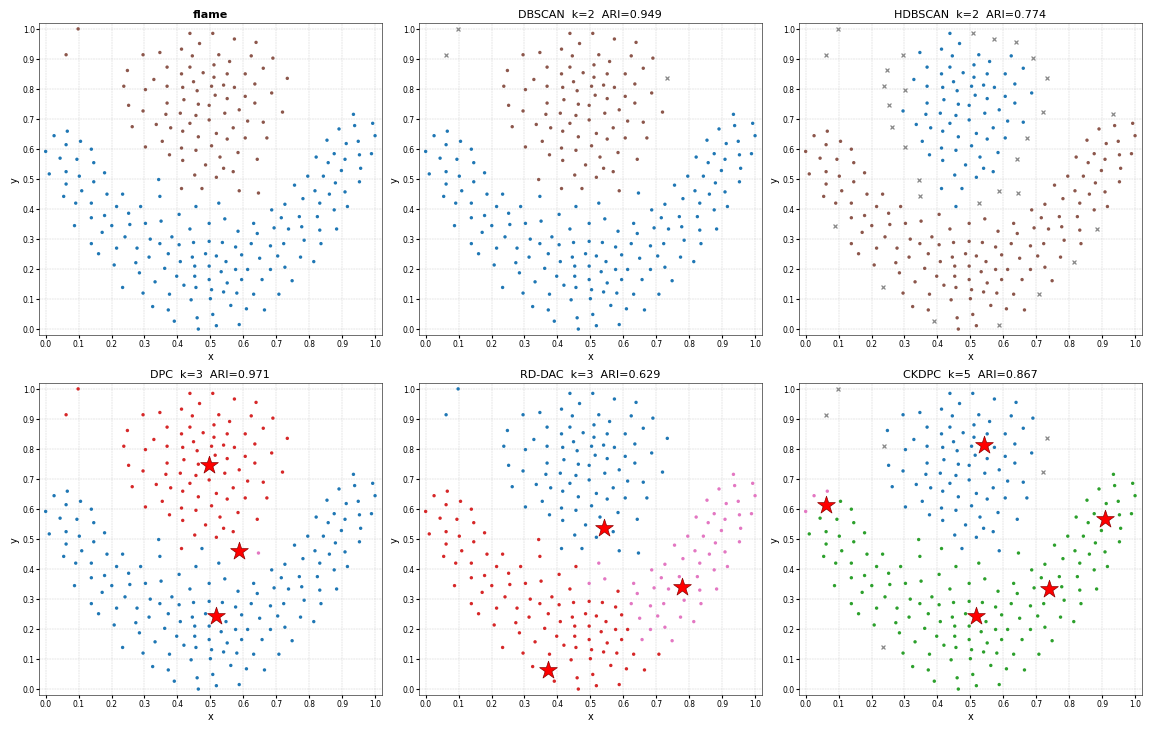

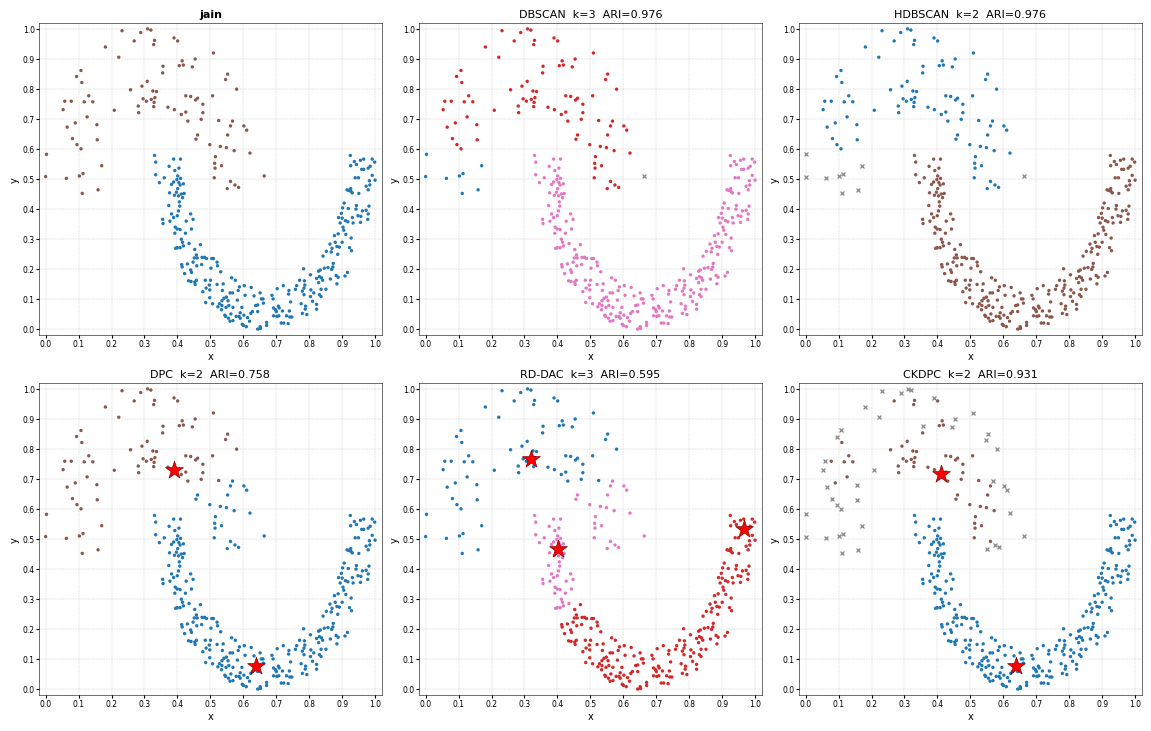

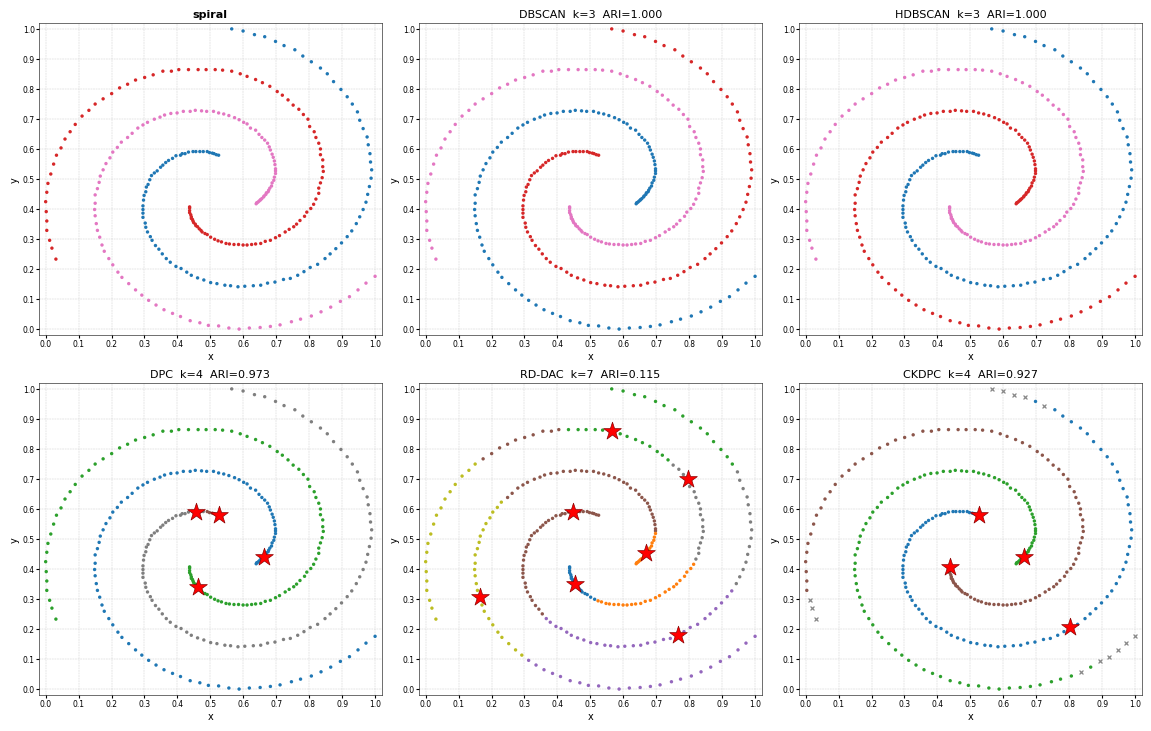

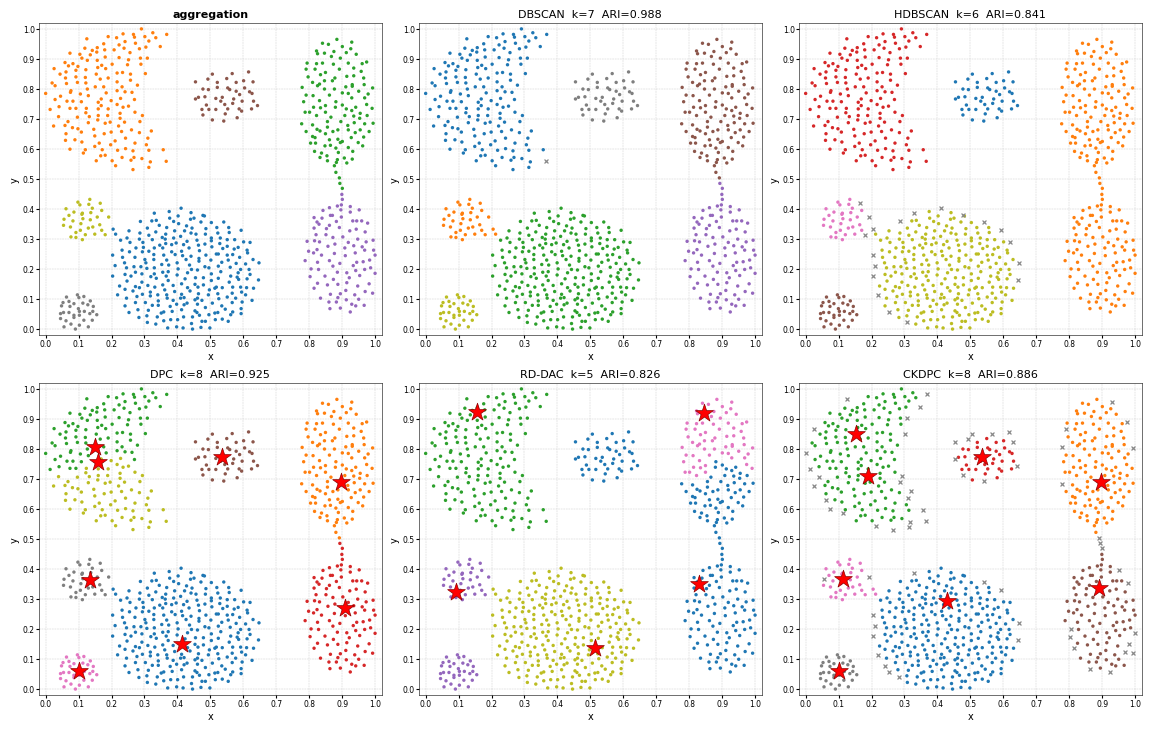

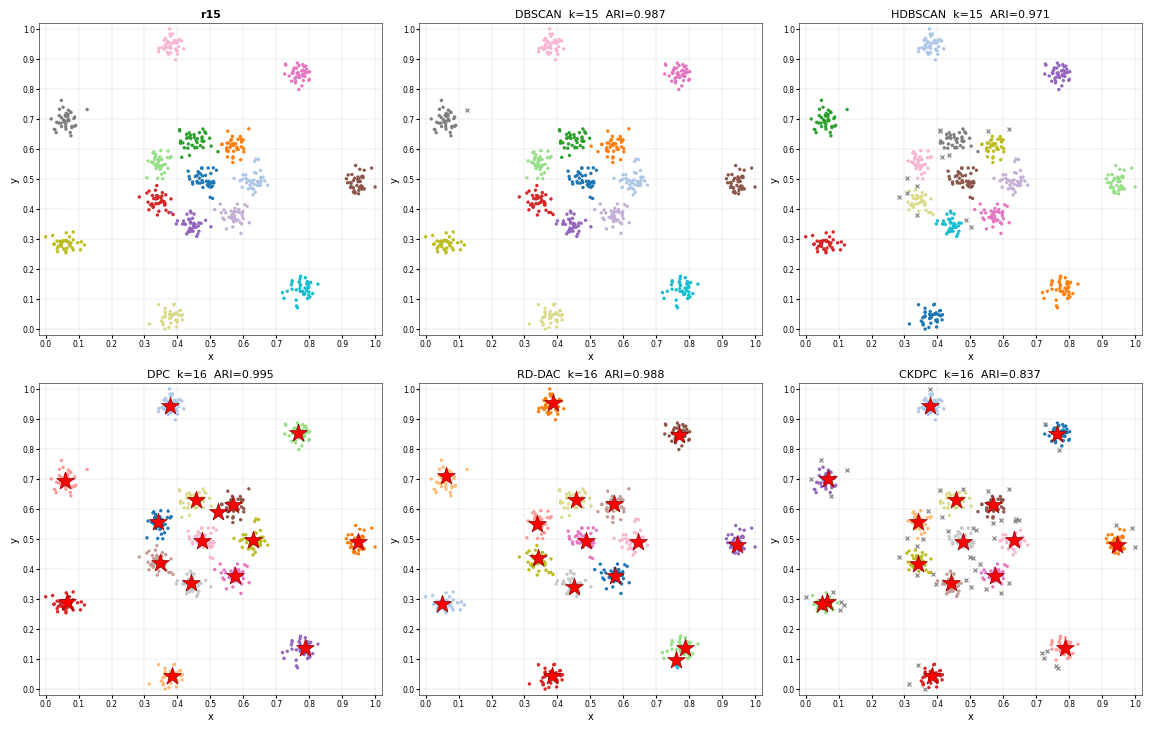

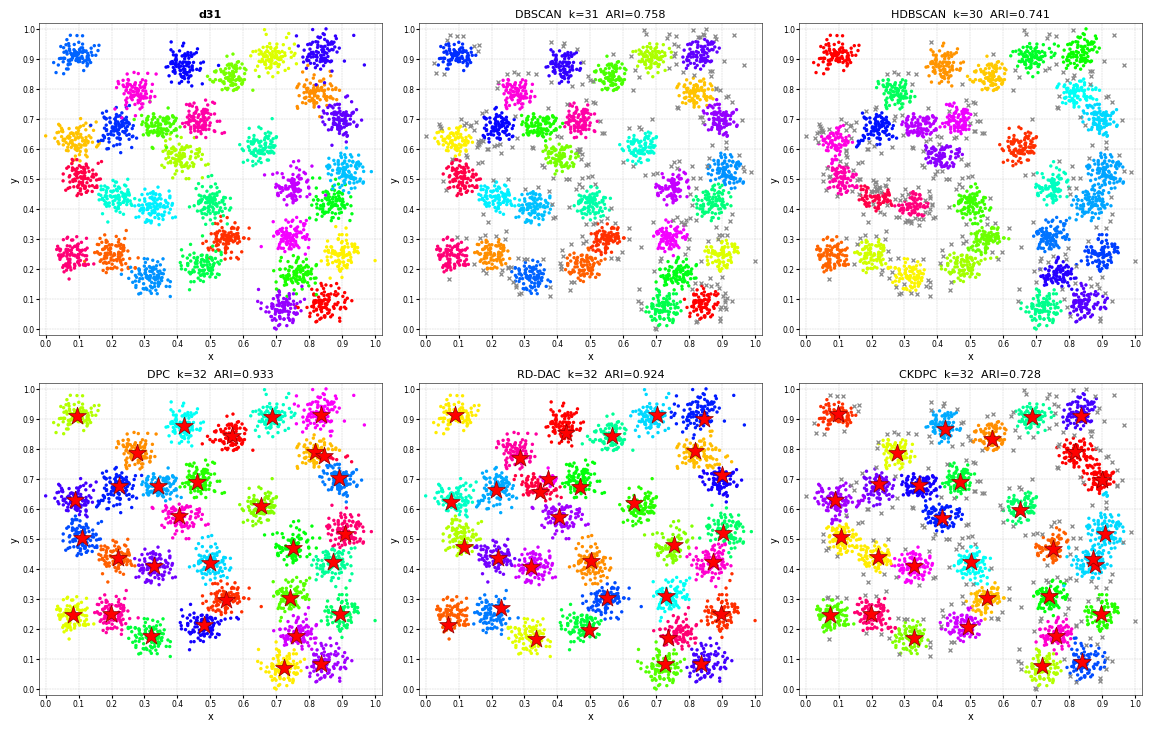

In [55]:
import os
os.makedirs('../results/synthetic_figures', exist_ok=True)

for dname, res in ALL_RESULTS.items():
    plot_dataset_results(dname, res,
                         save_path=f'../results/synthetic_figures/{dname}.png')

In [ ]:
summary = []
for dname, res in ALL_RESULTS.items():
    for alg in ALG_NAMES:
        m = res['rows'][alg]
        summary.append({
            'Dataset':   dname,
            'k_true':    res['k_true'],
            'Algorithm': alg,
            'k_found':   m['k_found'],
            'noise%':    round(m['noise_pct'], 1),
            'ARI':       round(m['ARI'], 4) if not (isinstance(m['ARI'], float) and m['ARI'] != m['ARI']) else None,
            'AMI':       round(m['AMI'], 4) if not (isinstance(m['AMI'], float) and m['AMI'] != m['AMI']) else None,
            'NMI':       round(m['NMI'], 4) if not (isinstance(m['NMI'], float) and m['NMI'] != m['NMI']) else None,
            'FMI':       round(m['FMI'], 4) if not (isinstance(m['FMI'], float) and m['FMI'] != m['FMI']) else None,
        })

df_sum = pd.DataFrame(summary)
df_pivot = df_sum.pivot_table(
    index='Algorithm',
    columns='Dataset',
    values=['ARI', 'AMI', 'NMI', 'FMI'],
    aggfunc='first'
)

df_pivot = df_pivot.swaplevel(axis=1).sort_index(axis=1)


display(df_pivot.style
    .format('{:.4f}', na_rep='-')
    .background_gradient(cmap='RdYlGn', axis=None, vmin=0, vmax=1)
    .set_caption('Внешние метрики')
)